In [1]:
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


In [2]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    'data/natural_images',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    validation_split=0.2,
    seed=42
)

Found 6899 files belonging to 8 classes.
Using 5520 files for training.


In [4]:
val_ds = keras.utils.image_dataset_from_directory(
    'data/natural_images',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    validation_split=0.2,
    seed=42
)

Found 6899 files belonging to 8 classes.
Using 1379 files for validation.


In [5]:
test_ds = keras.utils.image_dataset_from_directory(
    'data/natural_images',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 6899 files belonging to 8 classes.


In [6]:
class_names = train_ds.class_names
print(class_names)

['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


In [7]:
num_classes = len(class_names)
print(num_classes)

8


In [8]:

AUTOTUNE = tf.data.AUTOTUNE 

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [9]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [10]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_aug,
    layers.Rescaling(1.0/255),

    # Conv block 1: 32 filters, halve spatially
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Conv block 2: 64 filters
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Conv block 3: 128 filters
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Conv block 4: 128 filters
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Classifier head
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,096 (5.99 MB)

 Trainable params: 1,569,096 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 94s 513ms/step - accuracy: 0.5399 - loss: 1.2322 - val_accuracy: 0.7411 - val_loss: 0.7116
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 81s 471ms/step - accuracy: 0.7384 - loss: 0.7160 - val_accuracy: 0.8347 - val_loss: 0.4818
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 81s 468ms/step - accuracy: 0.7750 - loss: 0.6071 - val_accuracy: 0.8550 - val_loss: 0.4083
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 90s 518ms/step - accuracy: 0.8071 - loss: 0.5247 - val_accuracy: 0.8463 - val_loss: 0.4264
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 87s 501ms/step - accuracy: 0.8156 - loss: 0.4925 - val_accuracy: 0.8753 - val_loss: 0.3723
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 140s 489ms/step - accuracy: 0.8386 - loss: 0.4276 - val_accuracy: 0.8760 - val_loss: 0.3522
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 79s 454ms/step - accuracy: 0.8520 - loss: 0.4077 - val_accuracy: 0.8187 - val_loss: 0.4658
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 80s 464ms/step - accuracy: 0.8533 - loss: 

In [14]:
# Make sure test_ds exists
if 'test_ds' not in dir():
    test_ds = val_ds
    print("test_ds set to validation set")

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Extract training history
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

print(f"\n✅ Training history extracted:")
print(f"   Best validation accuracy: {max(val_acc):.4f}")
print(f"   Final training accuracy: {acc[-1]:.4f}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.9291 - loss: 0.1872

Test Accuracy: 0.9291 (92.91%)
Test Loss: 0.1872

✅ Training history extracted:
   Best validation accuracy: 0.9326
   Final training accuracy: 0.9007


In [15]:
acc      = history.history["accuracy"]      # training accuracy per epoch
val_acc  = history.history["val_accuracy"]  # validation accuracy per epoch
loss     = history.history["loss"]          # training loss per epoch
val_loss = history.history["val_loss"]      # validation loss per epoch

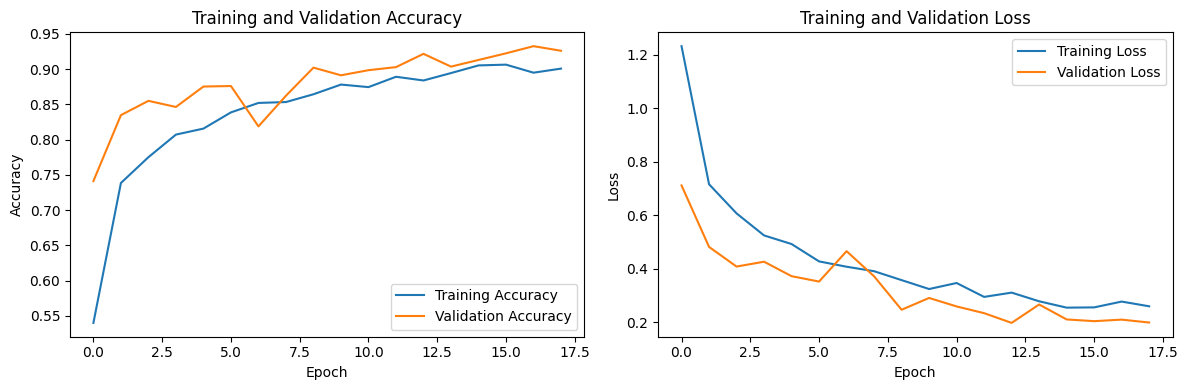

In [16]:
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

# Left chart: accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Right chart: loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

In [17]:
model.save("natural_images_cnn.keras")

In [19]:
import numpy as np
import tensorflow as tf
from keras.utils import load_img, img_to_array

def predict_new_image(img_path):
    """Predict class for any new image"""
    
    # Load and preprocess
    img = load_img(img_path, target_size=(150, 150))
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # ← DON'T FORGET THIS!
    img_batch = tf.expand_dims(img_array, 0)
    
    # Predict
    predictions = model.predict(img_batch, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = 100 * np.max(predictions[0])
    
    # Show image
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.1f}%")
    plt.axis('off')
    plt.show()
    
    print(f"✅ Predicted: {predicted_class} ({confidence:.1f}%)")
    return predicted_class, confidence

# Use it
# predict_new_image("your_image.jpg")